In [126]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from nltk.stem.snowball import SnowballStemmer
import seaborn  as sns
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import pickle
from sklearn.naive_bayes import MultinomialNB


In [101]:
import kagglehub
path = kagglehub.dataset_download("taruntiwarihp/phishing-site-urls")

Using Colab cache for faster access to the 'phishing-site-urls' dataset.


In [102]:
import os

# List the contents of the downloaded directory to find the CSV file
files_in_directory = os.listdir(path)
csv_file_name = None
for file in files_in_directory:
    if file.endswith('.csv'):
        csv_file_name = file
        break

if csv_file_name:
    full_csv_path = os.path.join(path, csv_file_name)
    df = pd.read_csv(full_csv_path)
    print(f"Successfully loaded {csv_file_name} into DataFrame.")
else:
    print("Error: No CSV file found in the downloaded directory.")


Successfully loaded phishing_site_urls.csv into DataFrame.


In [103]:
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [104]:
df.shape

(549346, 2)

In [105]:
df.describe()

,URL,Label
count,549346,549346
unique,507195,2
top,jhomitevd2abj3fk.onion.to/,good
freq,52,392924


In [106]:
df.isnull().sum()

,0
URL,0
Label,0


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [108]:
df.Label.value_counts()

,count
Label,
good,392924
bad,156422


In [109]:
token = RegexpTokenizer(r"[A-Za-z]+")

In [110]:
a=df.URL[0]
token.tokenize(a)

['nobell',
 'it',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'login',
 'SkyPe',
 'com',
 'en',
 'cgi',
 'bin',
 'verification',
 'login',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'index',
 'php',
 'cmd',
 'profile',
 'ach',
 'outdated',
 'page',
 'tmpl',
 'p',
 'gen',
 'failed',
 'to',
 'load',
 'nav',
 'login',
 'access']

In [111]:
df['text_token']=df.URL.map(lambda x:token.tokenize(x))

In [112]:
snowomer=SnowballStemmer("english")
df['text_weight']=df['text_token'].map(lambda x:[snowomer.stem(word) for word in x])

In [113]:
df['text'] = df['text_weight'].map(lambda x: ' '.join(x))

In [114]:
good=df[df['Label'] == 'good']
bad=df[df['Label'] == 'bad']


<Axes: xlabel='Label', ylabel='Count'>

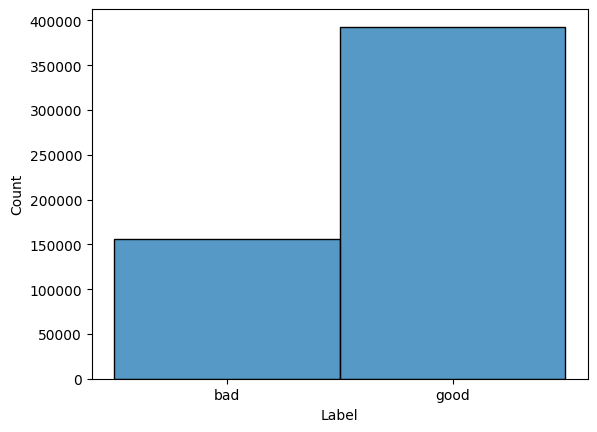

In [115]:
sns.histplot(df['Label'])

##  Forming Cloud of the by the help tokening

In [116]:
def plot_cloud(text, mask=None, max_font_size=125, figure_size=(25,20),
               title=None, title_size=40, title_color=None, image_color=False):

    stopwords = set(STOPWORDS)
    more_stopwords = {"com", "https"}
    stopwords = stopwords.union(more_stopwords)

    wordcloud = WordCloud(
        background_color="white",
        stopwords=stopwords,
        max_font_size=max_font_size,
        random_state=42,
        mask=mask
    )

    wordcloud.generate(str(text))

    plt.figure(figsize=figure_size)

    if image_color and mask is not None:
        image_colors = ImageColorGenerator(mask)
        plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear")
        plt.title(title, fontsize=title_size, color=title_color, verticalalignment="bottom")
    else:
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.title(title, fontsize=title_size)

    plt.axis("off")
    plt.tight_layout()
    plt.show()

Good Text WordCloud

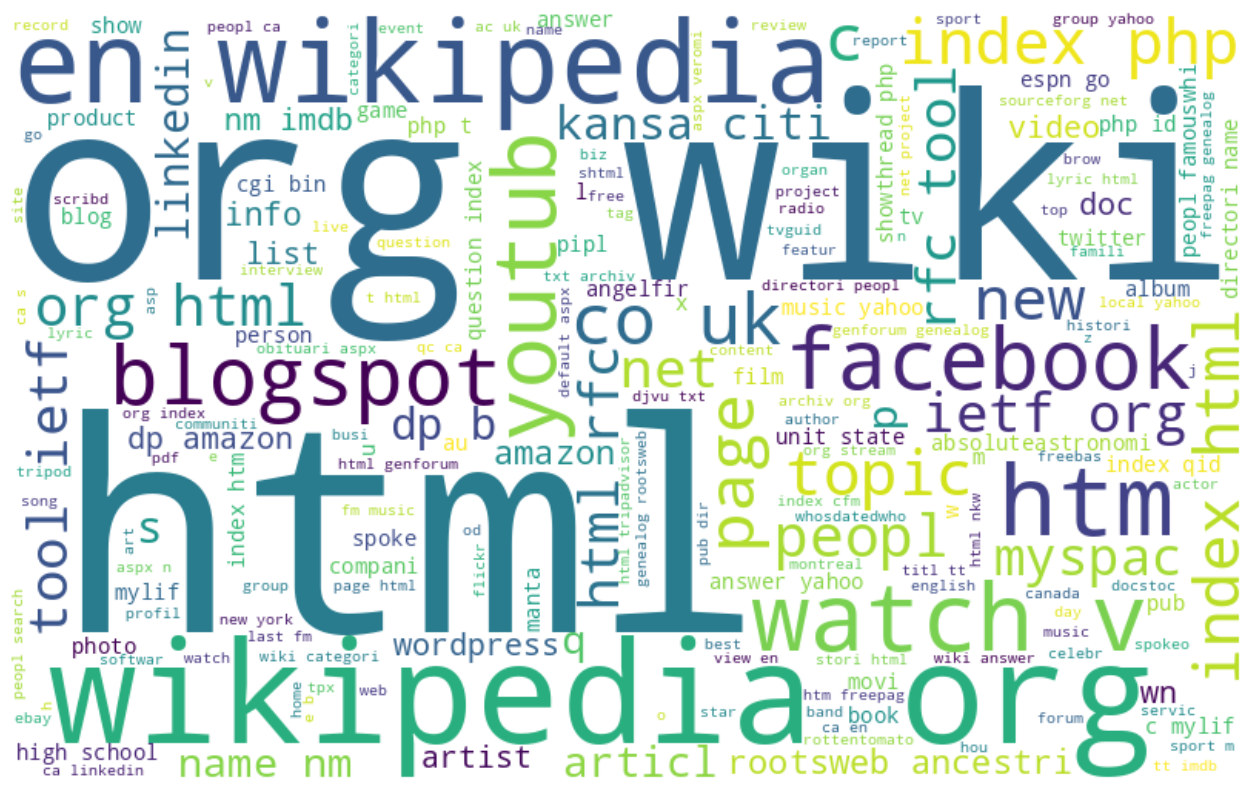

In [117]:
all_text=" ".join(good['text'].tolist())
wordcloud=WordCloud(width=800, height=500, background_color="white").generate(all_text)
plt.figure(figsize=(20,10))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.show()

Bad Text WordCloud

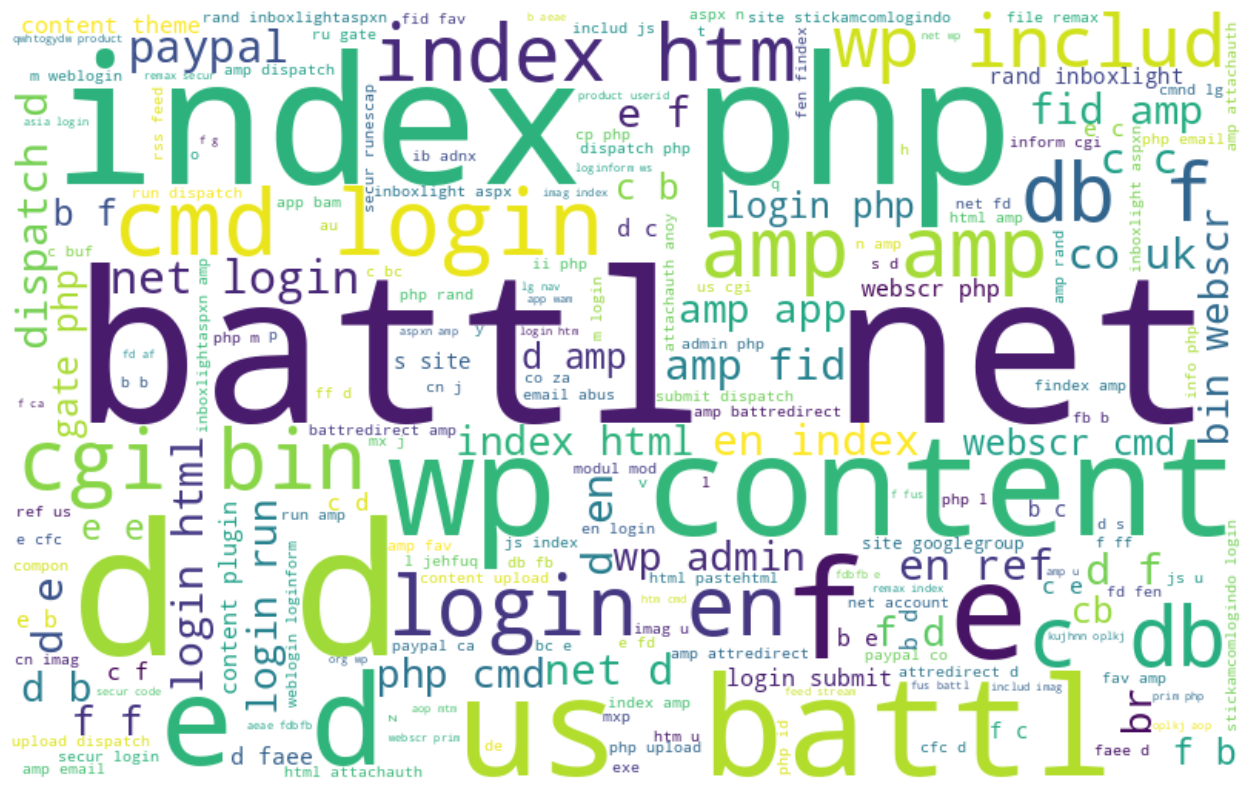

In [118]:
all_text=" ".join(bad['text'].tolist())
wordcloud=WordCloud(width=800, height=500, background_color="white").generate(all_text)
plt.figure(figsize=(20,10))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.show()

In [119]:
a=CountVectorizer()
feature=a.fit(df.text)
feature

CountVectorizer()

Train and Test Spilting

In [120]:
x_train,x_test,y_train,y_test=train_test_split(a.transform(df.text),df.Label)

## Model Training

Appying LogisticRegression

In [121]:
a= LogisticRegression()
a.fit(x_train,y_train)
print("Testing data score : ",a.score(  x_train,y_train),"\n")
print("Training data score",a.score(x_test,y_test),"\n")
print(" Report : \n")
print(classification_report(y_test,a.predict(x_test)))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Testing data score :  0.9779665007317802 

Training data score 0.9648455987825568 

 Report : 

              precision    recall  f1-score   support

         bad       0.97      0.91      0.94     39210
        good       0.96      0.99      0.98     98127

    accuracy                           0.96    137337
   macro avg       0.97      0.95      0.96    137337
weighted avg       0.96      0.96      0.96    137337



In [122]:
accuracy_score=accuracy_score(y_test,a.predict(x_test))
accuracy_score

0.9648455987825568

In [123]:
pickle.dump(a,open('model.pkl','wb'))

In [127]:
b=MultinomialNB()
b.fit(x_train,y_train)
print("Testing data score : ",b.score(  x_train,y_train),"\n")
print("Training data score",b.score(x_test,y_test),"\n")
print(" Report : \n")
print(classification_report(y_test,b.predict(x_test)))

Testing data score :  0.97405639197202 

Training data score 0.9573822058148933 

 Report : 

              precision    recall  f1-score   support

         bad       0.94      0.91      0.92     39210
        good       0.97      0.97      0.97     98127

    accuracy                           0.96    137337
   macro avg       0.95      0.94      0.95    137337
weighted avg       0.96      0.96      0.96    137337



In [128]:
pickle.dump(a,open('vector.pkl','wb'))

In [132]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import pickle
from sklearn.model_selection import train_test_split # Ensure train_test_split is available

# Step 1: Vectorization
# x_train and x_test currently hold CountVectorizer output (csr_matrix).
# TfidfVectorizer requires raw text.
# Let's perform a new train-test split on the original text data for TFIDF.
X_raw_train, X_raw_test, y_train_tfidf, y_test_tfidf = train_test_split(df.text, df.Label, test_size=0.25, random_state=42)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_raw_train)
X_test_vec = vectorizer.transform(X_raw_test)

# Step 2: Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train_tfidf)

# Step 3: Evaluate (optional but recommended)
accuracy = model.score(X_test_vec, y_test_tfidf)
print("Accuracy:", accuracy)

# Step 4: Save both
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

Accuracy: 0.9577389924055426
